# Parabolic time-domain Radon inversion

This example constructs a seismic forward model by composing a parabolic Radon operator with column-wise convolution:

$$
A = W R.
$$

`R` maps a $\tau-q$ model to a CMP-style gather and `W` convolves each trace with the same wavelet. Because both operators have adjoints, the composite operator can be used directly with iterative inverse solvers.

In [1]:
using Pkg
Pkg.activate("..")

using MiniOps
using Random
using LinearAlgebra
using Printf
using CairoMakie
using SeisProcessing

  Activating project at `~/MiniOps`


## 1. Geometry, model, and operators

For the parabolic Radon operator,

$$
d(t,x) = \sum_q m\!\left(t-q(x/x_{\rm ref})^2,q\right).
$$

The adjoint sums data samples back along the same parabolic trajectories.

In [7]:
dt = 0.002
h = collect(0:200) .* 10.0
q = collect(-100:100) .* 0.2 / 100
w = seismic_wavelet(dt=dt, f0=50.0)

nt = 200
nq = length(q)
href = maximum(h)

W = conv1d_cols_op(w)
R = radon_tx_parab_op(dt, h, q; href=href)
A = W * R

m = zeros(nt, nq)
m[100,101] =  1.0
m[120,120] = -1.0
m[ 60, 90] = -0.5
m[ 80,140] =  0.5

d = A * m
ma = A' * d;

The adjoint panel is not an inverse. It is a backprojection that is useful for checking the geometry and for constructing gradients.

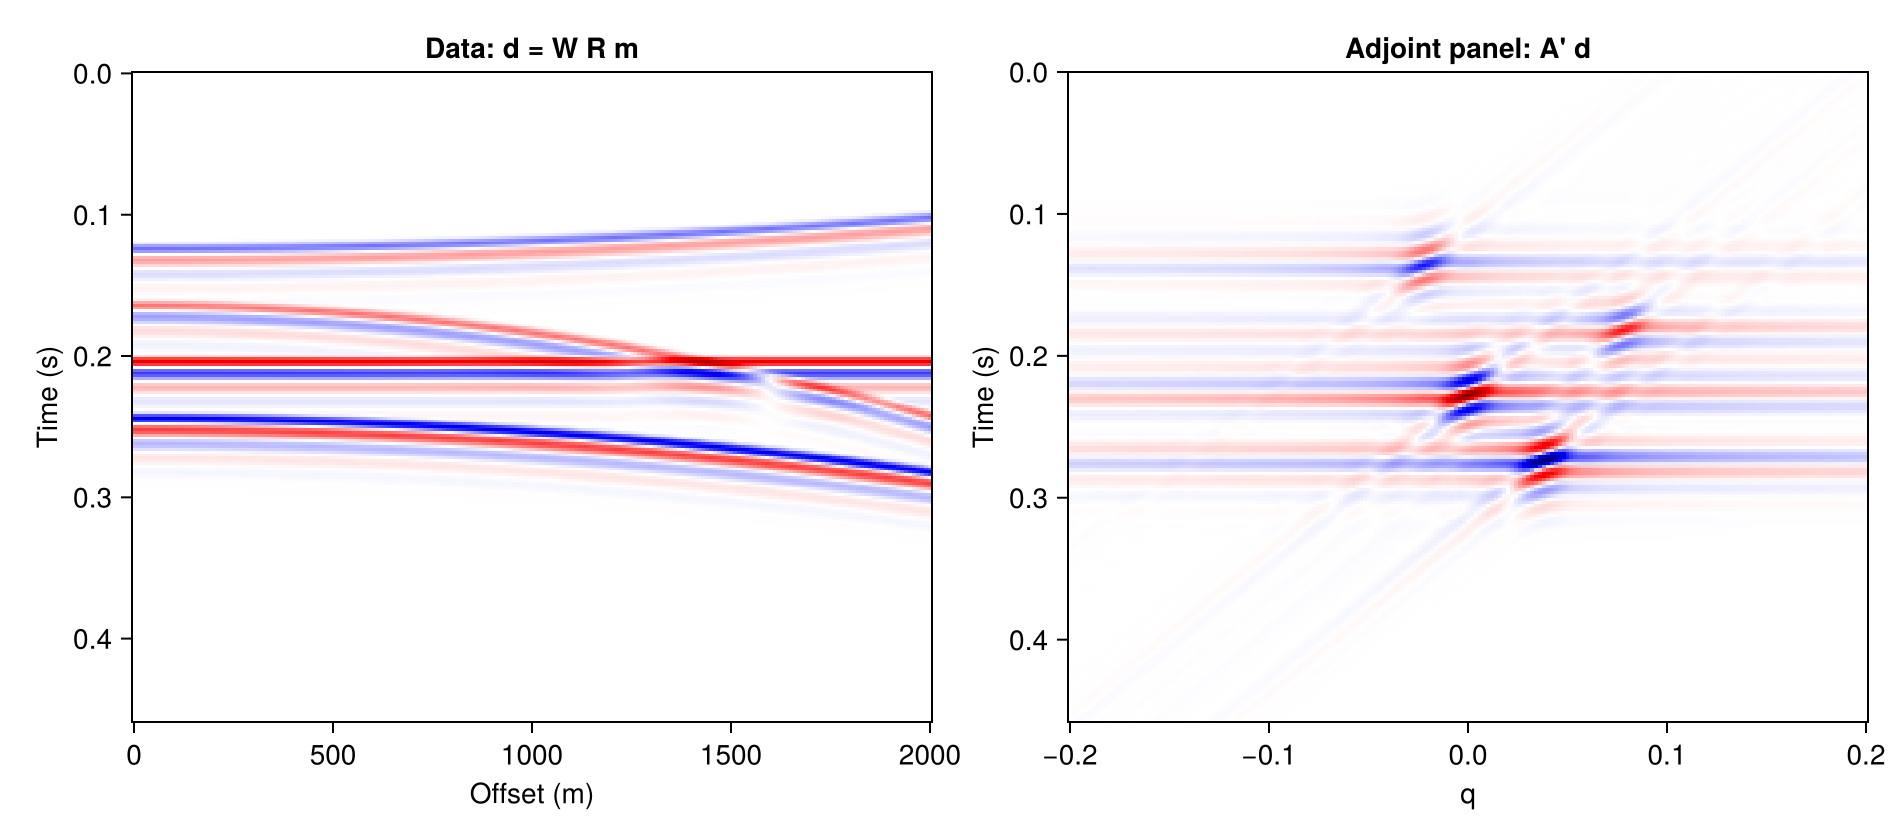

In [3]:
td = (0:size(d,1)-1) .* dt

fig = Figure(size=(950,420))
ax1 = Axis(fig[1,1], xlabel="Offset (m)", ylabel="Time (s)", title="Data: d = W R m", yreversed=true)
heatmap!(ax1, h, td, d'; colormap=:seismic, colorrange=(-1,1))

ax2 = Axis(fig[1,2], xlabel="q", ylabel="Time (s)", title="Adjoint panel: A' d", yreversed=true)
lim = maximum(abs.(ma))
heatmap!(ax2, q, td, ma'; colormap=:seismic, colorrange=(-lim,lim))
fig

## 2. Adjoint test

The composite operator should satisfy the dot-product identity before it is used in inversion.

In [4]:
adjoint_test(A, randn(size(m)), randn(size(d)); tol=1e-10)

(true, 3.3797156843667526e-16)

## 3. Sparse $\ell_2-\ell_1$ inversion

We estimate the Radon model with ISTA by minimizing a data-misfit term plus an \(\ell_1\) penalty. The operator norm estimate provides the step length.

In [8]:
m0 = zeros(Float64, nt, nq)
μ = 1.1
opn = opnorm_power(A, randn(nt,nq))
η = 0.97 / opn^2

mi = ista(A, d, m0, μ, η; niter=330, verbose=true)
dp = A * mi;


ISTA
    iter     rel_residual         residual             cost
------------------------------------------------------------
       0     1.000000e+00     2.188751e+01     2.395316e+02
      20     2.638732e-01     5.775528e+00     2.621300e+01
      40     1.977397e-01     4.328031e+00     1.859985e+01
      60     1.695619e-01     3.711289e+00     1.562693e+01
      80     1.526405e-01     3.340921e+00     1.390300e+01
     100     1.407635e-01     3.080963e+00     1.274749e+01
     120     1.319266e-01     2.887545e+00     1.190013e+01
     140     1.250694e-01     2.737458e+00     1.124338e+01
     160     1.195457e-01     2.616559e+00     1.072952e+01
     180     1.148960e-01     2.514788e+00     1.030164e+01
     200     1.108936e-01     2.427186e+00     9.935589e+00
     220     1.073706e-01     2.350075e+00     9.616547e+00
     240     1.043098e-01     2.283083e+00     9.340607e+00
     260     1.016096e-01     2.223982e+00     9.094597e+00
     280     9.921305e-02     2.1

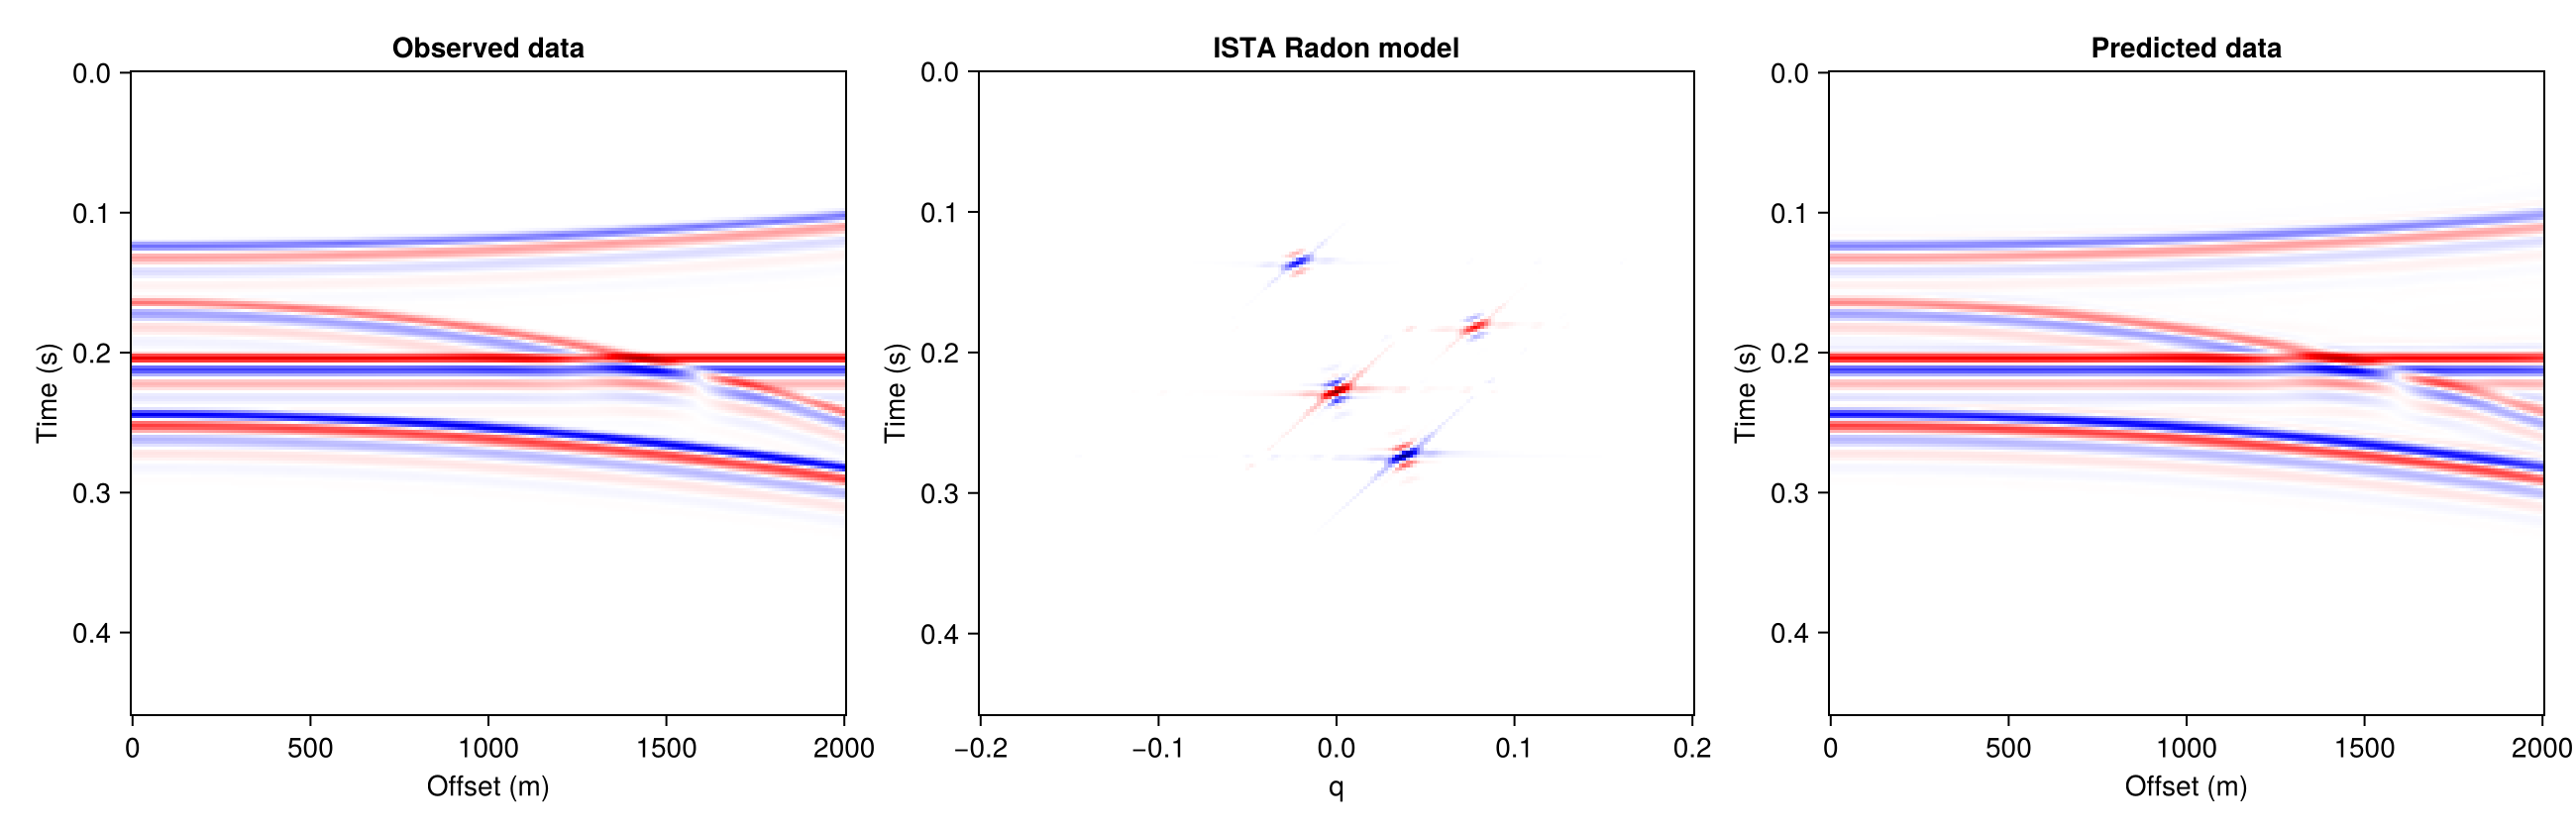

In [9]:
fig = Figure(size=(1300,420))

ax1 = Axis(fig[1,1], xlabel="Offset (m)", ylabel="Time (s)", title="Observed data", yreversed=true)
heatmap!(ax1, h, td, d'; colormap=:seismic, colorrange=(-1,1))

ax2 = Axis(fig[1,2], xlabel="q", ylabel="Time (s)", title="ISTA Radon model", yreversed=true)
limm = maximum(abs.(mi))
heatmap!(ax2, q, td, mi'; colormap=:seismic, colorrange=(-limm,limm))

ax3 = Axis(fig[1,3], xlabel="Offset (m)", ylabel="Time (s)", title="Predicted data", yreversed=true)
heatmap!(ax3, h, td, dp'; colormap=:seismic, colorrange=(-1,1))
fig